In [8]:
import pandas as pd

train_data = pd.read_csv("Training Dataset.csv")
test_data = pd.read_csv("Testing Dataset.csv")

print(train_data.head())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [9]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Load the dataset
train_data = pd.read_csv("Training Dataset.csv")

# Separate features and target variable from training data
X = train_data.drop(columns=["Loan_ID", "Loan_Status"])
y = train_data["Loan_Status"]

# Handle 'Dependents' special case
X['Dependents'] = X['Dependents'].replace('3+', 3)

# Handling missing values for numerical features
num_imputer = SimpleImputer(strategy='mean')
X['LoanAmount'] = num_imputer.fit_transform(X[['LoanAmount']])
X['Loan_Amount_Term'] = num_imputer.fit_transform(X[['Loan_Amount_Term']])
X['Credit_History'] = num_imputer.fit_transform(X[['Credit_History']])

# Handling missing values for categorical features
cat_imputer = SimpleImputer(strategy='most_frequent')
X['Gender'] = cat_imputer.fit_transform(X[['Gender']]).ravel()
X['Married'] = cat_imputer.fit_transform(X[['Married']]).ravel()
X['Dependents'] = cat_imputer.fit_transform(X[['Dependents']]).ravel()
X['Self_Employed'] = cat_imputer.fit_transform(X[['Self_Employed']]).ravel()

# Encoding categorical variables
label_encoder = LabelEncoder()
categorical_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']
for col in categorical_cols:
    X[col] = label_encoder.fit_transform(X[col])

# Encode target variable
y = label_encoder.fit_transform(y)

# Feature scaling
scaler = StandardScaler()
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

In [10]:
X['Total_Income'] = X['ApplicantIncome'] + X['CoapplicantIncome']

# Scale the new feature
X['Total_Income'] = scaler.fit_transform(X[['Total_Income']])

# Split the data into training and validation sets
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize and train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on validation data
y_pred = model.predict(X_val)

# Evaluate the model
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(classification_report(y_val, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))

Accuracy: 0.75
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.42      0.54        43
           1       0.75      0.93      0.83        80

    accuracy                           0.75       123
   macro avg       0.75      0.67      0.68       123
weighted avg       0.75      0.75      0.73       123

Confusion Matrix:
[[18 25]
 [ 6 74]]


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


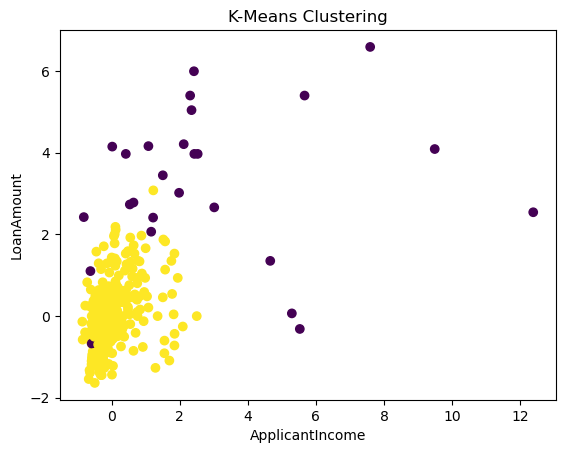

In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Applying K-Means Clustering
kmeans = KMeans(n_clusters=2, random_state=42)
X['Cluster'] = kmeans.fit_predict(X)

# Visualize the clusters
plt.scatter(X['ApplicantIncome'], X['LoanAmount'], c=X['Cluster'], cmap='viridis')
plt.xlabel('ApplicantIncome')
plt.ylabel('LoanAmount')
plt.title('K-Means Clustering')
plt.show()

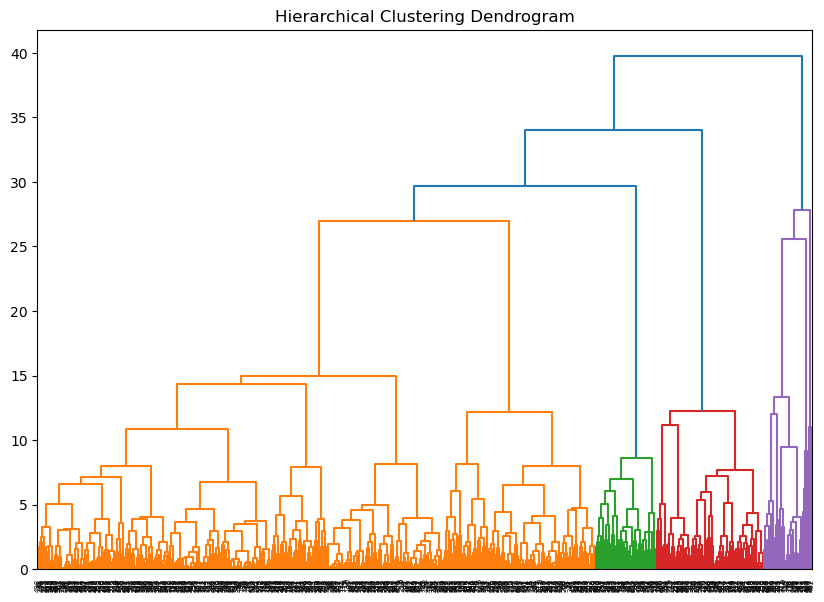

In [13]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Perform hierarchical/agglomerative clustering
linked = linkage(X, 'ward')

# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

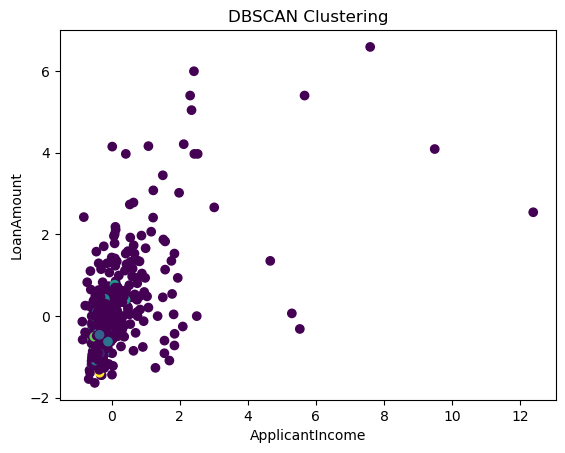

In [14]:
from sklearn.cluster import DBSCAN

# Applying DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
X['Cluster_DBSCAN'] = dbscan.fit_predict(X)

# Visualize the clusters
plt.scatter(X['ApplicantIncome'], X['LoanAmount'], c=X['Cluster_DBSCAN'], cmap='viridis')
plt.xlabel('ApplicantIncome')
plt.ylabel('LoanAmount')
plt.title('DBSCAN Clustering')
plt.show()

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


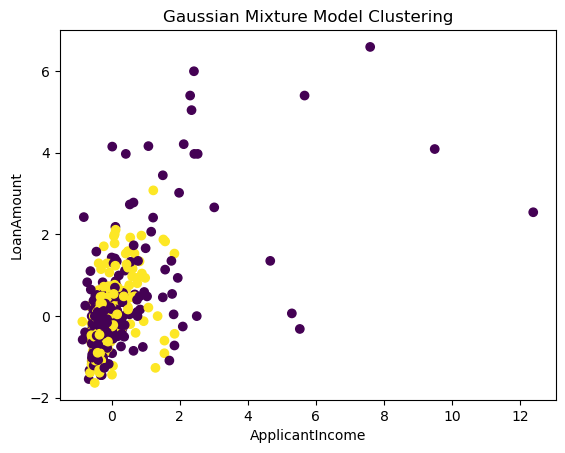

In [15]:
from sklearn.mixture import GaussianMixture

# Applying Gaussian Mixture Model
gmm = GaussianMixture(n_components=2, random_state=42)
X['Cluster_GMM'] = gmm.fit_predict(X)

# Visualize the clusters
plt.scatter(X['ApplicantIncome'], X['LoanAmount'], c=X['Cluster_GMM'], cmap='viridis')
plt.xlabel('ApplicantIncome')
plt.ylabel('LoanAmount')
plt.title('Gaussian Mixture Model Clustering')
plt.show()

In [16]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# Bagging
bagging = BaggingClassifier(base_estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42)
bagging.fit(X_train, y_train)
y_pred_bagging = bagging.predict(X_val)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


In [17]:
from sklearn.ensemble import AdaBoostClassifier

# Boosting
boosting = AdaBoostClassifier(n_estimators=100, random_state=42)
boosting.fit(X_train, y_train)
y_pred_boosting = boosting.predict(X_val)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, StackingClassifier

# Stacking
estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42))
]
stacking_model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stacking_model.fit(X_train, y_train)

StackingClassifier(estimators=[('rf', RandomForestClassifier(random_state=42)),
                               ('gb',
                                GradientBoostingClassifier(random_state=42))],
                   final_estimator=LogisticRegression())

In [20]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest.fit(X_train, y_train)
y_pred_rf = random_forest.predict(X_val)

In [21]:
gradient_boosting = GradientBoostingClassifier(n_estimators=100, random_state=42)
gradient_boosting.fit(X_train, y_train)
y_pred_gb = gradient_boosting.predict(X_val)

In [23]:
from sklearn.linear_model import LogisticRegression

# L1 Regularization
lasso = LogisticRegression(penalty='l1', solver='saga', max_iter=1000)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_val)

# L2 Regularization
ridge = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_val)

# ElasticNet Regularization
elastic_net = LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=1000)
elastic_net.fit(X_train, y_train)
y_pred_elastic_net = elastic_net.predict(X_val)